# LLM — Tópicos Fijos (7 categorías)

Few-shot prompting con taxonomía explícita de 7 categorías. Evaluación F1 sobre `test.txt`.

In [1]:
import sys
sys.path.append('..')

import pickle
import time
import json
import re
import os
from huggingface_hub import InferenceClient
from utils.metrics import compute_absa_metrics
import pandas as pd
import ast

/Users/lauraich/Documents/Maestría Inteligencia Artificial Aplicada/Trabajo de grado/ABSA/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
HF_TOKEN = os.environ.get('HF_TOKEN', 'XXXX')
MODEL_ID  = 'Qwen/Qwen2.5-7B-Instruct'

client = InferenceClient(model=MODEL_ID, token=HF_TOKEN)

In [3]:
CATEGORY_DESCRIPTIONS = {
    'facilities comfort': 'Comodidad en las instalaciones generales (zonas comunes, mobiliario de descanso).',
    'facilities design_features': 'Características de diseño y arquitectura de las instalaciones.',
    'facilities general': 'Comentarios generales sobre las instalaciones del hotel.',
    'facilities miscellaneous': 'Aspectos variados de las instalaciones no clasificados en otros puntos.',
    'facilities prices': 'Precio de los servicios o uso de las instalaciones.',
    'facilities quality': 'Calidad constructiva o de los materiales de las instalaciones.',
    'food_drinks prices': 'Precios de la comida, bebidas, restaurante o minibar.',
    'food_drinks quality': 'Calidad de los alimentos y bebidas servidos.',
    'food_drinks style_options': 'Variedad de opciones, menús, buffets o estilos culinarios.',
    'hotel cleanliness': 'Higiene y limpieza general de las áreas comunes del hotel.',
    'hotel comfort': 'Sensación general de comodidad y bienestar en el establecimiento.',
    'hotel design_features': 'Atributos estéticos o estructurales del edificio del hotel.',
    'hotel general': 'Opiniones globales sobre el hotel como un todo.',
    'hotel miscellaneous': 'Comentarios generales que no encajan en categorías específicas del hotel.',
    'hotel prices': 'Tarifas generales del hotel y valor percibido.',
    'hotel quality': 'Estándares de calidad percibidos en el establecimiento.',
    'location general': 'Ubicación, cercanía a puntos de interés y entorno.',
    'room_amenities cleanliness': 'Limpieza de los complementos de la habitación (toallas, albornoces).',
    'room_amenities comfort': 'Comodidad de los complementos (almohadas, mantas, amenities).',
    'room_amenities design_features': 'Diseño y estética de los complementos de la habitación.',
    'room_amenities general': 'Presencia y estado general de los artículos de cortesía y complementos.',
    'room_amenities quality': 'Calidad de los productos de baño y extras en la habitación.',
    'rooms cleanliness': 'Nivel de limpieza específico dentro de la habitación.',
    'rooms comfort': 'Confort térmico, acústico y ergonomía de la habitación.',
    'rooms design_features': 'Distribución, decoración y diseño del interior de la habitación.',
    'rooms general': 'Comentarios generales sobre la habitación sin especificar un atributo.',
    'rooms miscellaneous': 'Aspectos secundarios de la habitación.',
    'rooms prices': 'Costo específico de la habitación o suplementos.',
    'rooms quality': 'Calidad del mobiliario y materiales dentro de la habitación.',
    'service general': 'Trato del personal, eficiencia en el check-in y atención al cliente.'
}

# 2. Generación de la cadena de categorías para el prompt
CATS_STR = '\n'.join(f'- {cat}: {desc}' for cat, desc in CATEGORY_DESCRIPTIONS.items())

In [4]:
CATEGORIES = [
    "facilities comfort",
    "facilities design_features",
    "facilities general",
    "facilities miscellaneous",
    "facilities prices",
    "facilities quality",
    "food_drinks prices",
    "food_drinks quality",
    "food_drinks style_options",
    "hotel cleanliness",
    "hotel comfort",
    "hotel design_features",
    "hotel general",
    "hotel miscellaneous",
    "hotel prices",
    "hotel quality",
    "location general",
    "polarity positive",
    "room_amenities cleanliness",
    "room_amenities comfort",
    "room_amenities design_features",
    "room_amenities general",
    "room_amenities quality",
    "rooms cleanliness",
    "rooms comfort",
    "rooms design_features",
    "rooms general",
    "rooms miscellaneous",
    "rooms prices",
    "rooms quality",
    "service general"
]

In [5]:
def parse_dataset(filepath):
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            content = parts[-1] if parts else ''
            if '####' in content:
                text, anns_str = content.split('####', 1)
                try:
                    annotations = ast.literal_eval(anns_str)
                except Exception:
                    annotations = []
            else:
                text, annotations = content, []
            if text.strip():
                data.append({'text': text.strip(), 'annotations': annotations})
    return data

In [6]:
train_data = parse_dataset('../data/train.txt')

def map_category(raw_cat):
    if not raw_cat: return None
    clean_cat = raw_cat.strip().lower()
    return clean_cat if clean_cat in CATEGORY_DESCRIPTIONS else None

FEW_SHOT_EXAMPLES = []
# Tomamos los primeros 5 ejemplos que tengan anotaciones válidas
for d in train_data: # Buscamos en los primeros 10 para asegurar 5 válidos
    pairs = []
    for term, raw_cat, polarity in d['annotations']:
        mapped = map_category(raw_cat)
        if mapped:
            pairs.append({
                'aspecto': term, 
                'categoria': mapped, 
                'polaridad': polarity
            })
    
    if pairs and len(FEW_SHOT_EXAMPLES) < 5:
        FEW_SHOT_EXAMPLES.append({
            'review': d['text'],
            'output': pairs
        })

# 4. Construcción del string para el prompt (Few-Shot)
examples_str = ''
for ex in FEW_SHOT_EXAMPLES:
    examples_str += f"Review: {ex['review']}\nRespuesta: {json.dumps(ex['output'], ensure_ascii=False)}\n\n"

print(examples_str)


Review: La ubicación del hotel está cerca de todo, es decir, tiendas, tranvías, etc.
Respuesta: [{"aspecto": "ubicación", "categoria": "location general", "polaridad": "positive"}]

Review: Teníamos 3 habitaciones, todas con 2 camas, a este precio
Respuesta: [{"aspecto": "NULL", "categoria": "hotel prices", "polaridad": "positive"}]

Review: Limpio y nuevo Hotel
Respuesta: [{"aspecto": "Hotel", "categoria": "hotel cleanliness", "polaridad": "positive"}, {"aspecto": "Hotel", "categoria": "hotel quality", "polaridad": "positive"}]

Review: Ambiente agradable personal, bonito habitación y tranquilo.
Respuesta: [{"aspecto": "personal", "categoria": "service general", "polaridad": "positive"}, {"aspecto": "habitación", "categoria": "rooms design_features", "polaridad": "positive"}, {"aspecto": "habitación", "categoria": "rooms comfort", "polaridad": "positive"}]

Review: Maravilloso Acabo de regresar de una estancia de tres noches en el NY Palace, debo decir que realmente no entiendo por qu

In [7]:
SYSTEM_PROMPT = f'''Eres un analizador de reseñas hoteleras en español. Dado un texto, identifica qué aspectos del hotel se mencionan y su polaridad.
Categorías disponibles:
{CATS_STR}

Reglas:
- Solo usa las categorías listadas arriba.
- Polaridad: positive, negative o neutral.
- Una review puede tener múltiples categorías.
- Responde SOLO con un JSON válido: [{{"categoria": "...", "polaridad": "..."}}]
- Si no se menciona ningún aspecto, responde: []
'''

def build_prompt(review_text):
    return f"{examples_str}Review: {review_text}\nRespuesta:"

In [8]:
def parse_llm_response(text):
    text = text.strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass
    match = re.search(r'\[.*?\]', text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group())
        except Exception:
            pass
    return []

def predict_aspects(review_text):
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': build_prompt(review_text)},
    ]
    try:
        # Añadimos un pequeño delay para evitar el Rate Limit de la API gratuita
        time.sleep(0.5) 
        response = client.chat_completion(messages=messages, max_tokens=256, temperature=0.1)
        raw = response.choices[0].message.content
        return parse_llm_response(raw)
    except Exception as e:
        # Esto te permitirá ver en la consola por qué está fallando (Token, Conexión, etc.)
        print(f"Error en la petición: {e}")
        return []

## Evaluación sobre test.txt

In [9]:
import ast

test_data = parse_dataset('../data/test.txt')
test_data = [d for d in test_data if d['annotations']]

ground_truth = []
for d in test_data:
    pairs = set()
    for term, raw_cat, polarity in d['annotations']:
        mapped = map_category(raw_cat)
        if mapped:
            pairs.add((mapped, polarity))
    ground_truth.append(pairs)

print(f'{len(test_data)} reviews a procesar')

584 reviews a procesar


In [10]:
predictions = []
errors = 0
t0 = time.time()

for i, d in enumerate(test_data[:20]):
    try:
        raw_pred = predict_aspects(d['text'])
        print(f"Predicción cruda: {raw_pred}")
        pairs = set()
        for item in raw_pred:
            cat = item.get('categoria', '')
            pol = item.get('polaridad', '')
            if cat in CATEGORIES and pol in ('positive', 'negative', 'neutral'):
                pairs.add((cat, pol))
        predictions.append(pairs)
    except Exception as e:
        predictions.append(set())
        errors += 1

    if (i + 1) % 50 == 0:
        elapsed = time.time() - t0
        print(f'{i+1}/{len(test_data)} — {1000*elapsed/(i+1):.0f}ms/review — errores: {errors}')

elapsed = time.time() - t0
print(f'\nTotal: {elapsed:.1f}s — {1000*elapsed/len(test_data):.1f}ms/review — errores: {errors}')

Predicción cruda: [{'aspecto': 'Residence Foch', 'categoria': 'hotel general', 'polaridad': 'positive'}, {'aspecto': 'ubicación', 'categoria': 'location general', 'polaridad': 'positive'}]
Predicción cruda: [{'aspecto': 'personal', 'categoria': 'service general', 'polaridad': 'positive'}]
Predicción cruda: [{'aspecto': 'personal', 'categoria': 'service general', 'polaridad': 'positive'}]
Predicción cruda: [{'aspecto': 'habitación', 'categoria': 'rooms design_features', 'polaridad': 'positive'}, {'aspecto': 'habitación', 'categoria': 'rooms comfort', 'polaridad': 'negative'}, {'aspecto': 'habitación', 'categoria': 'rooms general', 'polaridad': 'negative'}]
Predicción cruda: [{'aspecto': 'restaurantes', 'categoria': 'food_drinks style_options', 'polaridad': 'neutral'}]
Predicción cruda: [{'aspecto': 'ducha', 'categoria': 'rooms comfort', 'polaridad': 'negative'}]
Predicción cruda: []
Predicción cruda: [{'aspecto': 'alojamiento', 'categoria': 'hotel prices', 'polaridad': 'positive'}]
Erro

In [11]:
metrics = compute_absa_metrics(predictions, ground_truth)
print('=== Métricas LLM tópicos fijos ===')
for k, v in metrics.items():
    print(f'  {k:<20} {v:.4f}')
print(f'  ms/review:           {1000*elapsed/len(test_data):.1f}')

=== Métricas LLM tópicos fijos ===
  precision_micro      0.9810
  recall_micro         0.9810
  f1_micro             0.9810
  precision_macro      0.8416
  recall_macro         0.6238
  f1_macro             0.6794
  ms/review:           37.0


### Prueba con modelo local

In [12]:
len(test_data)

584

In [13]:
# ── Celda: Configuración del cliente Ollama ──────────────────────────────────
import requests, json, time, re

OLLAMA_URL  = "http://localhost:11434/api/chat"
OLLAMA_MODEL = "llama3:8b" 

def predict_aspects_ollama(review_text, model=OLLAMA_MODEL):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": build_prompt(review_text)},
    ]
    payload = {
        "model": model,
        "messages": messages,
        "stream": False,
        "think": False,          # desactiva thinking mode (Qwen3)
        "options": {"temperature": 0.1, "num_predict": 512}
    }
    resp = requests.post(OLLAMA_URL, json=payload, timeout=120)
    resp.raise_for_status()
    raw = resp.json()["message"]["content"]
    return parse_llm_response(raw)


In [14]:
# ── Celda: Evaluación con Ollama ─────────────────────────────────────────────
predictions_ollama = []
errors_ollama = 0
t0 = time.time()

for i, d in enumerate(test_data):  
    try:
        raw_pred = predict_aspects_ollama(d['text'])
        print(f"[{i+1}] {raw_pred}")
        pairs = set()
        for item in raw_pred:
            cat = item.get('categoria', '')
            pol = item.get('polaridad', '')
            if cat in CATEGORIES and pol in ('positive', 'negative', 'neutral'):
                pairs.add((cat, pol))
        predictions_ollama.append(pairs)
    except Exception as e:
        predictions_ollama.append(set())
        errors_ollama += 1
        print(f"[{i+1}] Error: {e}")

elapsed_ollama = time.time() - t0
print(f'\nTotal: {elapsed_ollama:.1f}s  |  {1000*elapsed_ollama/20:.1f}ms/review  |  errores: {errors_ollama}')


[1] [{'aspecto': 'Residence Foch', 'categoria': 'hotel general', 'polaridad': 'positive'}, {'aspecto': 'área', 'categoria': 'location general', 'polaridad': 'positive'}]
[2] [{'aspecto': 'personal', 'categoria': 'service general', 'polaridad': 'positive'}]
[3] [{'aspecto': 'personal', 'categoria': 'service general', 'polaridad': 'positive'}]
[4] [{'aspecto': 'habitación', 'categoria': 'rooms design_features', 'polaridad': 'neutral'}, {'aspecto': 'habitación', 'categoria': 'rooms comfort', 'polaridad': 'negative'}]
[5] [{'aspecto': 'restaurantes', 'categoria': 'location general', 'polaridad': 'positive'}]
[6] [{'aspecto': 'ducha', 'categoria': 'room_amenities cleanliness', 'polaridad': 'negative'}]
[7] []
[8] [{'aspecto': 'asequible alojamiento', 'categoria': 'rooms prices', 'polaridad': 'positive'}]
[9] [{'aspecto': 'personal', 'categoria': 'service general', 'polaridad': 'positive'}]
[10] [{'aspecto': 'USS Constallation', 'categoria': 'location general', 'polaridad': 'positive'}]
[11]

In [15]:
# ── Celda: Métricas Ollama ───────────────────────────────────────────────────
metrics_ollama = compute_absa_metrics(predictions_ollama, ground_truth[:20])
print(f'=== Métricas LLM tópicos fijos — Ollama ({OLLAMA_MODEL}) ===')
for k, v in metrics_ollama.items():
    print(f'  {k:<20} {v:.4f}')
print(f'  ms/review:           {1000*elapsed_ollama/20:.1f}')


=== Métricas LLM tópicos fijos — Ollama (llama3:8b) ===
  precision_micro      0.9819
  recall_micro         0.9819
  f1_micro             0.9819
  precision_macro      0.7643
  recall_macro         0.7458
  f1_macro             0.7547
  ms/review:           46043.7


## Análisis de errores y métricas

### ¿Qué mide cada métrica?

El problema ABSA se trata como **clasificación multi-label**: para cada par `(categoría, polaridad)` posible se predice si está presente o no en cada reseña.

| Métrica | Qué mide | Cuándo es útil |
|---------|----------|----------------|
| **Precision micro** | De todos los pares predichos como presentes, ¿qué fracción lo estaban realmente? (TP / (TP + FP)) — calcula sobre todos los ejemplos a la vez | Cuando queremos saber si el modelo «habla con fundamento» |
| **Recall micro** | De todos los pares que realmente estaban presentes, ¿qué fracción detectó el modelo? (TP / (TP + FN)) | Cuando importa no perder ningún aspecto anotado |
| **F1 micro** | Media armónica de precision y recall micro. Domina por las etiquetas frecuentes | Evaluación global equilibrada |
| **Precision macro** | Promedio no ponderado de la precision por cada etiqueta. Las etiquetas raras tienen el mismo peso | Detectar si el modelo falla en categorías poco frecuentes |
| **Recall macro** | Ídem para recall | Ídem |
| **F1 macro** | Media armónica de precision y recall macro | Evalúa equidad entre categorías: penaliza más los fallos en etiquetas raras |

> **Micro vs macro en ABSA:** Un F1 micro alto con F1 macro bajo indica que el modelo funciona bien en las categorías frecuentes (`rooms general`, `service general`) pero falla en las raras (`facilities prices`, `food_drinks style_options`).


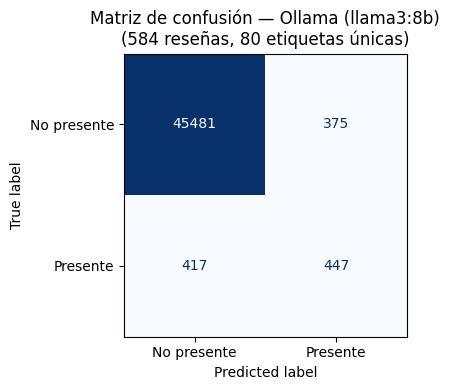

  TP (correcto presente):     447
  FP (falso positivo):        375
  FN (falso negativo):        417
  TN (correcto no presente):  45481
  Precision = TP/(TP+FP) = 0.5438
  Recall    = TP/(TP+FN) = 0.5174


In [16]:
# ── Matriz de confusión — Ollama ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def build_binary_vectors(preds, gts):
    n = min(len(preds), len(gts))
    all_labels = sorted({pair for gt in gts[:n] for pair in gt} |
                        {pair for p  in preds[:n] for pair in p})
    y_true, y_pred = [], []
    for gt, pred in zip(gts[:n], preds[:n]):
        for lbl in all_labels:
            y_true.append(int(lbl in gt))
            y_pred.append(int(lbl in pred))
    return np.array(y_true), np.array(y_pred), all_labels

y_true_ol, y_pred_ol, all_labels_ol = build_binary_vectors(predictions_ollama, ground_truth)
cm_ol = confusion_matrix(y_true_ol, y_pred_ol, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_ol,
                       display_labels=['No presente', 'Presente']
                       ).plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title(f'Matriz de confusión — Ollama ({OLLAMA_MODEL})\n'
             f'({len(predictions_ollama)} reseñas, {len(all_labels_ol)} etiquetas únicas)')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_ol.ravel()
print(f'  TP (correcto presente):     {tp}')
print(f'  FP (falso positivo):        {fp}')
print(f'  FN (falso negativo):        {fn}')
print(f'  TN (correcto no presente):  {tn}')
print(f'  Precision = TP/(TP+FP) = {tp/(tp+fp):.4f}' if (tp+fp)>0 else '  Precision = N/A')
print(f'  Recall    = TP/(TP+FN) = {tp/(tp+fn):.4f}' if (tp+fn)>0 else '  Recall    = N/A')
